## Import Libraries

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../scripts')
from data_preprocessing import *

#### Load Data

In [2]:
# Set up input and output paths
RAW_DATA_DIR = '../data/raw'
PROCESSED_DATA_DIR = '../data/processed'

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Load raw data
movies_file = os.path.join(RAW_DATA_DIR, 'movies_metadata.csv')
ratings_file = os.path.join(RAW_DATA_DIR, 'ratings_small.csv')

movies = pd.read_csv(movies_file)
ratings = pd.read_csv(ratings_file)

display(movies.head())
display(ratings.head())

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


,userId,movieId,rating,timestamp
0,1,1923,2.0,943228491
1,1,232,5.0,943228442
2,1,608,2.0,944248943
3,1,1136,1.0,943228327
4,1,166,5.0,943228442


#### Data Parsing and processing

In [3]:
movies['genres'] = movies['genres'].apply(parse_genres)

In [4]:
process_data(movies, ratings)


display(movies.head)
display(ratings.tail)

<bound method NDFrame.head of        adult                              belongs_to_collection    budget  \
0      False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1      False                                                NaN  65000000   
2      False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3      False                                                NaN  16000000   
4      False  {'id': 96871, 'name': 'Father of the Bride Col...         0   
...      ...                                                ...       ...   
45461  False                                                NaN         0   
45462  False                                                NaN         0   
45463  False                                                NaN         0   
45464  False                                                NaN         0   
45465  False                                                NaN         0   

                             genres          

<bound method NDFrame.tail of          userId movieId  rating   timestamp
0             1    1923     2.0   943228491
1             1     232     5.0   943228442
2             1     608     2.0   944248943
3             1    1136     1.0   943228327
4             1     166     5.0   943228442
...         ...     ...     ...         ...
3200015  200948     377     3.5  1203438264
3200016  200948    2706     4.5  1203426630
3200017  200948    2571     5.0  1203427483
3200018  200948   46965     1.0  1203439143
3200019  200948    1240     5.0  1203425836

[3200020 rows x 4 columns]>

In [5]:
check_movie_ids_consistency(movies)

Found date-like IDs in movies
1997-08-20
2012-09-29
2014-01-01
Dropped 3 movies with date-like IDs.


In [6]:
unique_movie_ids_in_movies = movies['id'].nunique()
unique_movie_ids_in_ratings = ratings['movieId'].nunique()

movies['id'] = movies['id'].astype(int)
ratings['movieId'] = ratings['movieId'].astype(int)

print(f"Unique movie IDs in movies dataset: {unique_movie_ids_in_movies}")
print(f"Unique movie IDs in ratings dataset: {unique_movie_ids_in_ratings}")


Unique movie IDs in movies dataset: 45433
Unique movie IDs in ratings dataset: 42646


In [7]:
movies.to_csv("../data/processed/movies_clean.csv", index=False)
print("cleaned movies file saved")
ratings.to_csv("../data/processed/ratings_clean.csv", index=False)
print("cleaned ratings file saved")

cleaned movies file saved
cleaned ratings file saved


## EDA Visualizations

#### 1. Distribution of release years

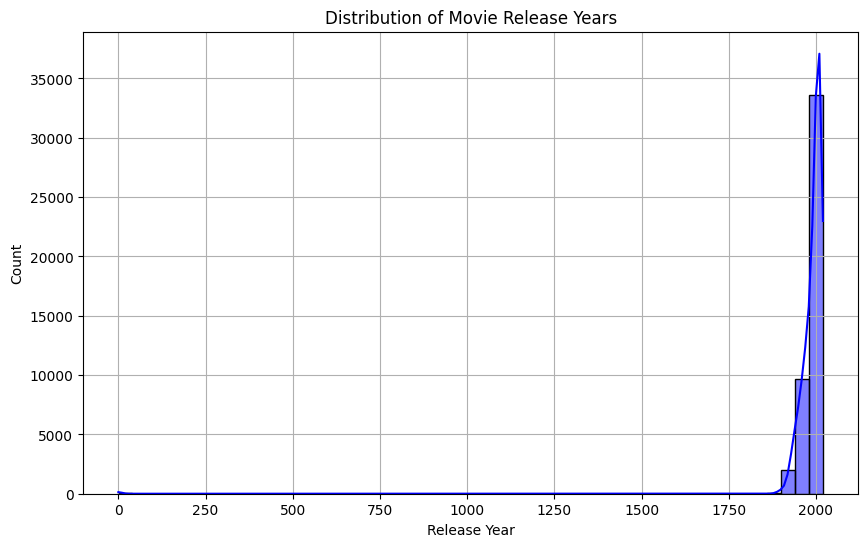

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(movies['release_year'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 2. Top 10 most common genres

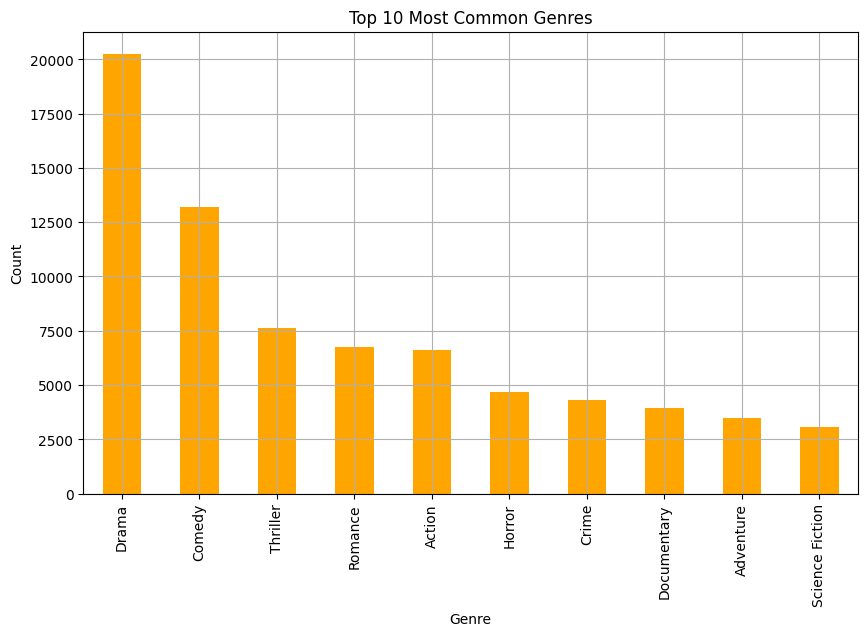

In [9]:
# Calculate genre counts
genre_counts = pd.Series([genre for genres_list in movies['genres'] for genre in genres_list]).value_counts()

# Plot the top 10 most common genres
plt.figure(figsize=(10, 6))
genre_counts.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 3. Distribution of movie popularity

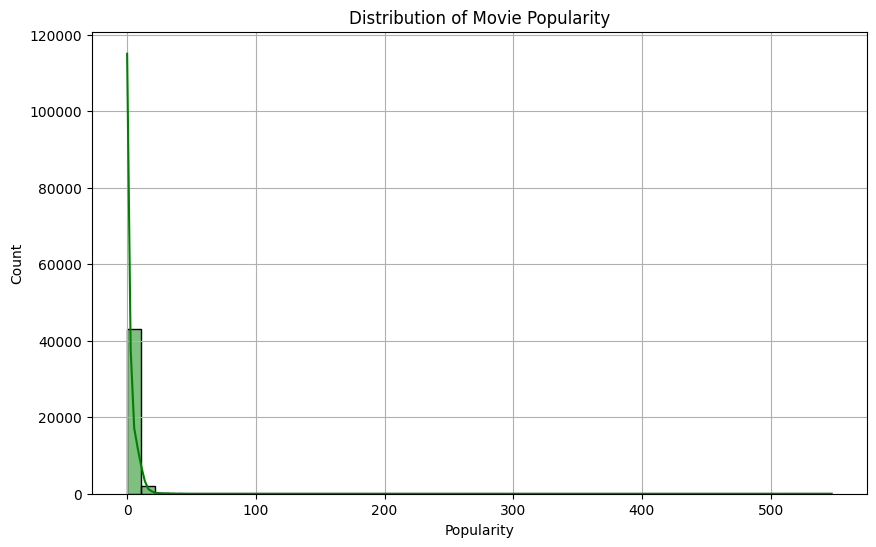

In [10]:

# Convert 'popularity' column to numeric, coercing errors to NaN
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.histplot(movies['popularity'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Movie Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 4. Distribution of vote averages

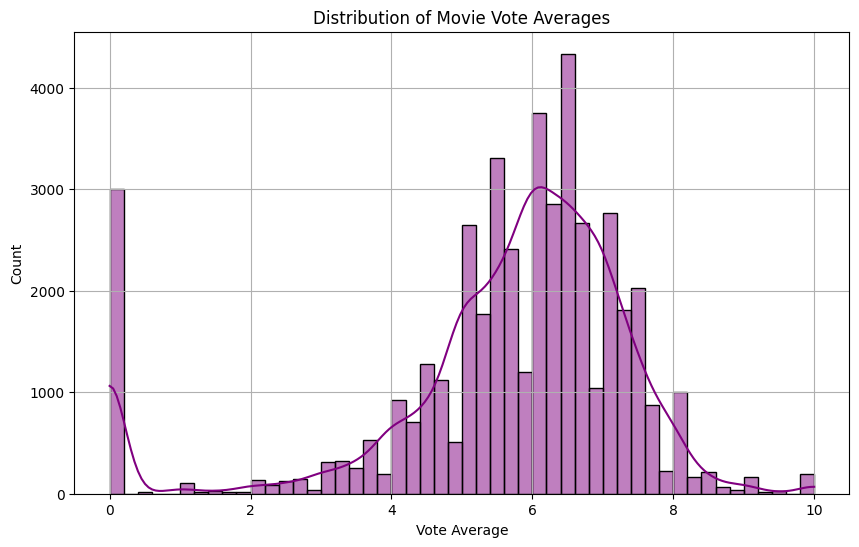

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(movies['vote_average'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Movie Vote Averages')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 5. Ratings distribution

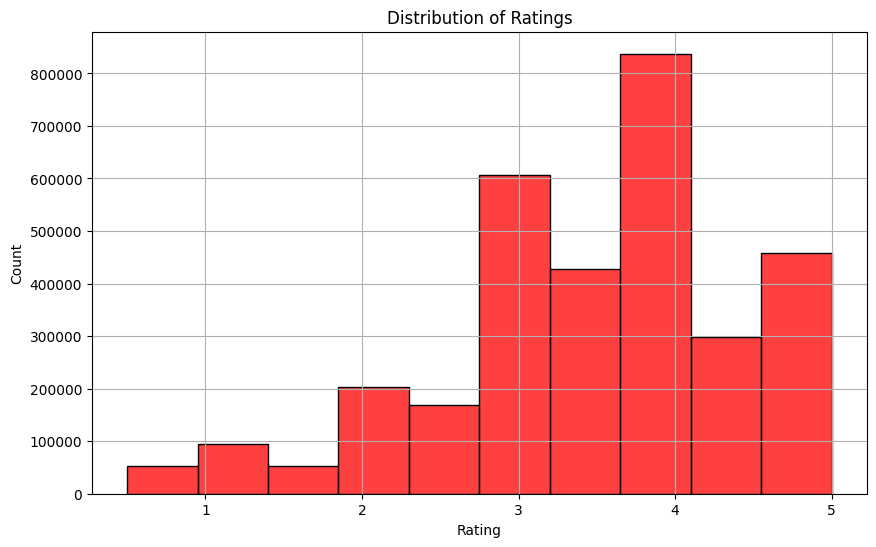

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=10, kde=False, color='red')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 6. Number of ratings per movie (Top 10 most rated movies)

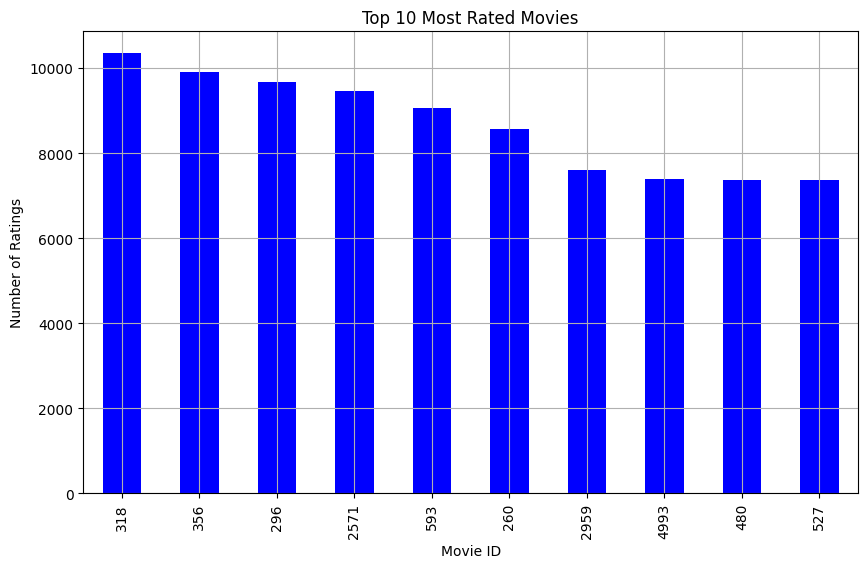

In [13]:
ratings_count = ratings.groupby('movieId').size().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ratings_count.head(10).plot(kind='bar', color='blue')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Movie ID')
plt.ylabel('Number of Ratings')
plt.grid()
plt.show()

#### 7. Average rating per movie

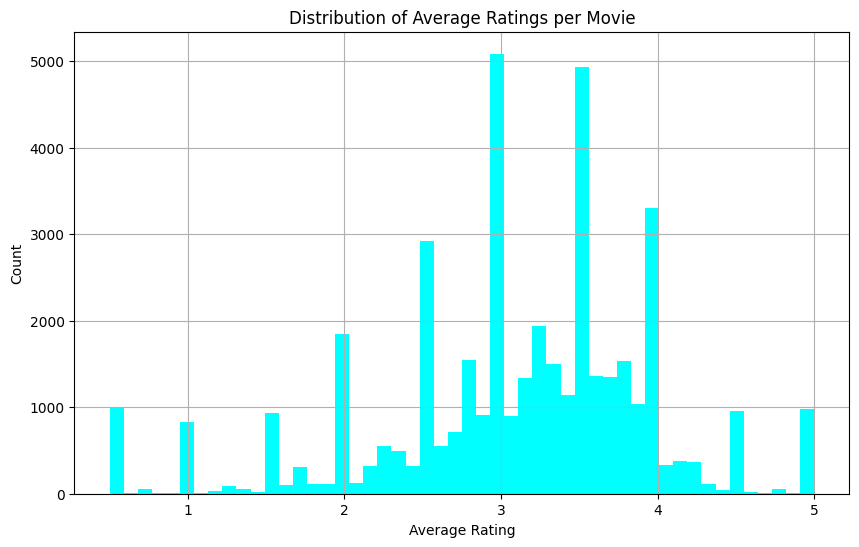

In [14]:
average_ratings = ratings.groupby('movieId')['rating'].mean()
plt.figure(figsize=(10, 6))
average_ratings.plot(kind='hist', bins=50, color='cyan')
plt.title('Distribution of Average Ratings per Movie')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.grid()
plt.show()